# 🛢️ Machine Learning em Dutos de Óleo e Gás

**Autores:** Fernando Garcia Rangel e Leonardo dos Santos Rodrigues  
**Instituição:** UniLaSalle-RJ — Bacharelado em Sistemas de Informação  
**Orientador:** Prof. George Hamilton 
**Ano:** 2026

---

## Objetivo

Desenvolver modelos de Machine Learning para prever a **taxa de crescimento da corrosão** em dutos de óleo e gás, a partir de dados históricos de inspeções por PIG (Pipeline Inspection Gauge).

O projeto testa dois cenários:
- 📗 **Com manutenção** — duto que recebeu intervenções periódicas
- 📕 **Sem manutenção** — duto com deterioração natural

E dois tipos de problema:
- 🔢 **Regressão** — prever a taxa exata de corrosão em %/ano
- 🏷️ **Classificação** — classificar o risco em: Baixo / Médio / Alto (`classe_risco_enc`)

---

## Estrutura do Notebook

| Seção | Conteúdo |
|---|---|
| 1 | Importações e Configurações |
| 2 | Carregamento e Tratamento dos Dados |
| 3 | Construção do Dataset de Transições |
| 4 | Análise Exploratória dos Dados (EDA) |
| 5 | Divisão Treino / Validação / Teste |
| 6 | Treinamento dos Modelos |
| 7 | Avaliação — Classificação |
| 8 | Avaliação — Regressão |
| 9 | Comparativo Final dos Modelos |

---
## 1. Importações e Configurações

Carregamos todas as bibliotecas necessárias. Se alguma não estiver instalada, rode:
```
pip install scikit-learn xgboost pandas matplotlib seaborn openpyxl
```

In [47]:
import warnings
warnings.filterwarnings('ignore')

# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Pré-processamento
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Modelos de Classificação
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Modelos de Regressão
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# ⚠️ Para usar XGBoost real (mais rápido), descomente após instalar:
# from xgboost import XGBClassifier, XGBRegressor

# Métricas
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score,
    mean_absolute_error, mean_squared_error, r2_score
)

# Estilo dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'Arial'

print('✅ Todas as bibliotecas carregadas com sucesso!')

✅ Todas as bibliotecas carregadas com sucesso!


### Configurações Globais

Definimos aqui as constantes que serão usadas em todo o notebook.  
Alterar aqui reflete automaticamente em todo o restante do código.

In [48]:
from pathlib import Path

# ── Arquivos de entrada (pasta Dados/Tratados dentro de Tcc) ────────────────
_cwd = Path.cwd()
if (_cwd / 'Dados' / 'Tratados').is_dir():
    _PASTA_TRATADOS = _cwd / 'Dados' / 'Tratados'
elif (_cwd / 'Tcc' / 'Dados' / 'Tratados').is_dir():
    _PASTA_TRATADOS = _cwd / 'Tcc' / 'Dados' / 'Tratados'
else:
    _PASTA_TRATADOS = Path('Dados') / 'Tratados'

ARQUIVO_COM = _PASTA_TRATADOS / 'dataset_com_manutencao.xlsx'
ARQUIVO_SEM = _PASTA_TRATADOS / 'dataset_sem_manutencao.xlsx'

# ── Features utilizadas pelos modelos (nomes iguais às colunas do Excel) ───
FEATURES = [
    'ano',
    'posicao_m',
    'dist_sold_ant_m',
    'compr_tubo_m',
    'ie_enc',
    'tipo_enc',
    'pos_horaria_graus',
    'esp_mm',
    'compr_mm',
    'larg_mm',
    'prof_pct',
    'erf',
    'tipo_pof_enc'
]

TARGET_CLASS = 'classe_risco_enc'   # classificação: 0=Baixo, 1=Medio, 2=Alto
TARGET_REG   = 'taxa_corrosao_ano'  # regressão (%/ano); desativado se ausente no Excel

CLASSES_NOMES = ['Baixo', 'Medio', 'Alto']
CLASSES_CORES = ['#27AE60', '#F39C12', '#E74C3C']

RANDOM_STATE = 42

print('✅ Configurações definidas.')
print(f'   Pasta dos Excel: {_PASTA_TRATADOS.resolve()}')
print(f'   Features: {len(FEATURES)} variáveis de entrada')
print(f'   Target classificação: {TARGET_CLASS}')
print(f'   Target regressão: {TARGET_REG}')

✅ Configurações definidas.
   Pasta dos Excel: D:\MachineLearning\Tcc\Dados\Tratados
   Features: 13 variáveis de entrada
   Target classificação: classe_risco_enc
   Target regressão: taxa_corrosao_ano


---
## 2. Carregamento dos Dados

Carregamos os datasets já tratados gerados na etapa de pré-processamento.  
Cada arquivo contém 4 abas: `dataset_completo`, `treino`, `validacao` e `teste`.

In [49]:
def carregar_dataset(filepath, nome):
    """Carrega as 4 abas de um dataset tratado."""
    completo  = pd.read_excel(filepath, sheet_name='dataset_completo')
    treino    = pd.read_excel(filepath, sheet_name='treino')
    validacao = pd.read_excel(filepath, sheet_name='validacao')
    teste     = pd.read_excel(filepath, sheet_name='teste')

    # Treino final = treino + validação combinados
    treino_val = pd.concat([treino, validacao], ignore_index=True)

    print(f'📂 {nome}')
    print(f'   Total:     {len(completo):>5} registros')
    print(f'   Treino:    {len(treino):>5} ({len(treino)/len(completo)*100:.0f}%)')
    print(f'   Validação: {len(validacao):>5} ({len(validacao)/len(completo)*100:.0f}%)')
    print(f'   Teste:     {len(teste):>5} ({len(teste)/len(completo)*100:.0f}%)')
    print()

    return completo, treino_val, validacao, teste


df_com, tv_com, val_com, tst_com = carregar_dataset(ARQUIVO_COM, 'COM Manutenção')
df_sem, tv_sem, val_sem, tst_sem = carregar_dataset(ARQUIVO_SEM, 'SEM Manutenção')

📂 COM Manutenção
   Total:      1384 registros
   Treino:     1107 (80%)
   Validação:   138 (10%)
   Teste:       139 (10%)

📂 SEM Manutenção
   Total:      1617 registros
   Treino:     1293 (80%)
   Validação:   162 (10%)
   Teste:       162 (10%)



### Verificação rápida do dataset
Vamos dar uma olhada nas primeiras linhas e nos tipos de dados para confirmar que tudo carregou corretamente.

In [50]:
print('=== Dataset COM Manutenção — primeiras linhas ===')
df_com.head(3)

=== Dataset COM Manutenção — primeiras linhas ===


,split,ano,id_tubo,posicao_m,dist_sold_ant_m,compr_tubo_m,ie,ie_enc,tipo,tipo_enc,pos_horaria_graus,esp_mm,compr_mm,larg_mm,prof_pct,erf,tipo_pof,tipo_pof_enc,classe_risco,classe_risco_enc
0,treino,2015,191041102,18.017,0.000,12.260,-,0,ASCI,0,312.5,8.7,11,60,17,0.62,CIGR,1,Baixo,0
1,teste,2015,191047614,104.842,12.090,12.091,-,0,ASCI,0,90.0,7.1,41,91,14,0.77,GENE,2,Baixo,0
2,treino,2015,191057413,275.293,0.012,11.952,-,0,COSC,3,180.0,7.1,10,47,10,0.76,CIGR,1,Baixo,0


In [51]:
print('=== Tipos de dados e valores nulos ===')
_cols_info = FEATURES + [TARGET_CLASS]
if TARGET_REG is not None and TARGET_REG in df_com.columns:
    _cols_info = _cols_info + [TARGET_REG]
df_com[_cols_info].info()

=== Tipos de dados e valores nulos ===
<class 'pandas.DataFrame'>
RangeIndex: 1384 entries, 0 to 1383
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ano                1384 non-null   int64  
 1   posicao_m          1384 non-null   float64
 2   dist_sold_ant_m    1384 non-null   float64
 3   compr_tubo_m       1384 non-null   float64
 4   ie_enc             1384 non-null   int64  
 5   tipo_enc           1384 non-null   int64  
 6   pos_horaria_graus  1384 non-null   float64
 7   esp_mm             1384 non-null   float64
 8   compr_mm           1384 non-null   int64  
 9   larg_mm            1384 non-null   int64  
 10  prof_pct           1384 non-null   int64  
 11  erf                1384 non-null   float64
 12  tipo_pof_enc       1384 non-null   int64  
 13  classe_risco_enc   1384 non-null   int64  
dtypes: float64(6), int64(8)
memory usage: 151.5 KB


---
## 3. Análise Exploratória dos Dados (EDA)

Antes de treinar qualquer modelo, é essencial entender a distribuição dos dados.  
Aqui respondemos perguntas como:
- As classes estão balanceadas?
- Como a taxa de corrosão se distribui?
- Existe diferença clara entre os dois cenários?

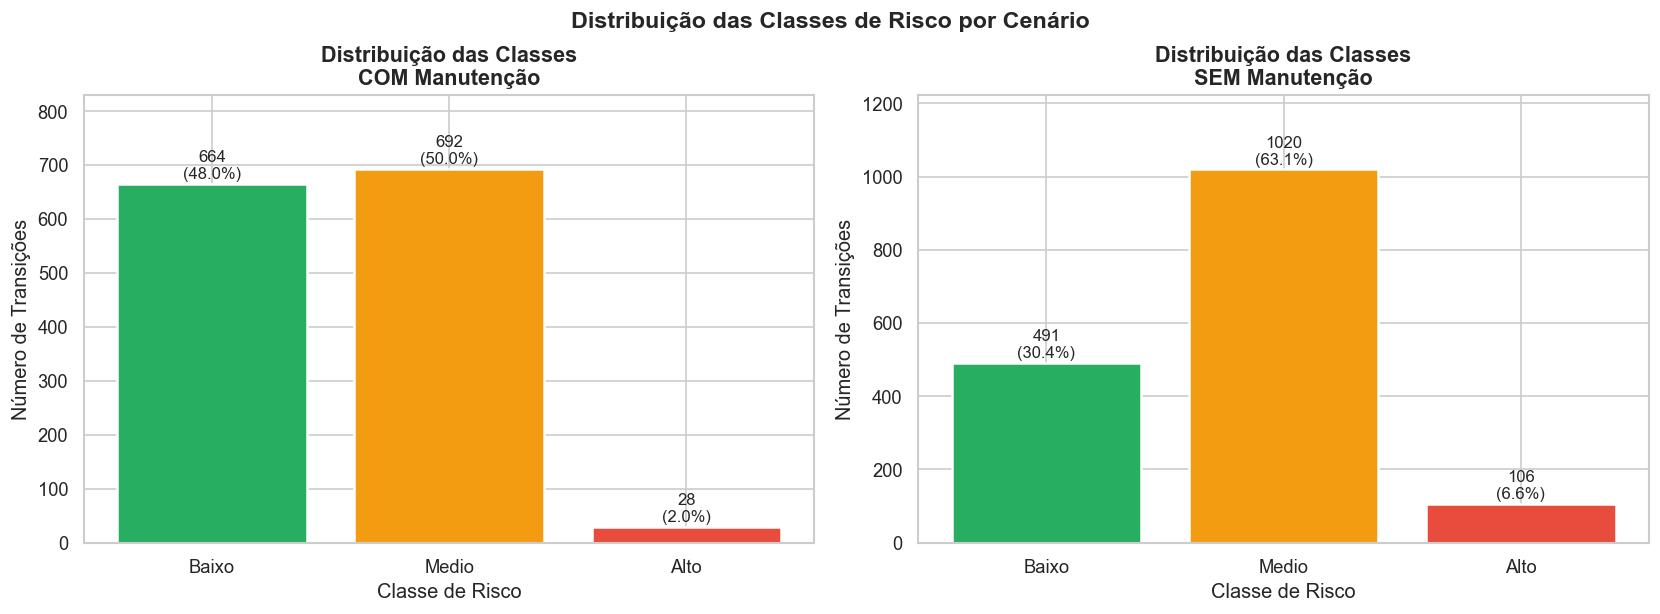

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, nome, cor) in zip(axes, [
    (df_com, 'COM Manutenção', '#2E75B6'),
    (df_sem, 'SEM Manutenção', '#C0392B')
]):
    ordem_cls = ['Baixo', 'Medio', 'Alto']
    counts = df['classe_risco'].value_counts().reindex(ordem_cls, fill_value=0)
    bars = ax.bar(counts.index, counts.values,
                  color=CLASSES_CORES,
                  edgecolor='white', linewidth=1.5)
    ax.set_title(f'Distribuição das Classes\n{nome}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Classe de Risco')
    ax.set_ylabel('Número de Transições')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{val}\n({val/counts.sum()*100:.1f}%)',
                ha='center', va='bottom', fontsize=10)
    ax.set_ylim(0, counts.max() * 1.2)

plt.tight_layout()
plt.suptitle('Distribuição das Classes de Risco por Cenário', y=1.02,
             fontsize=14, fontweight='bold')
plt.show()

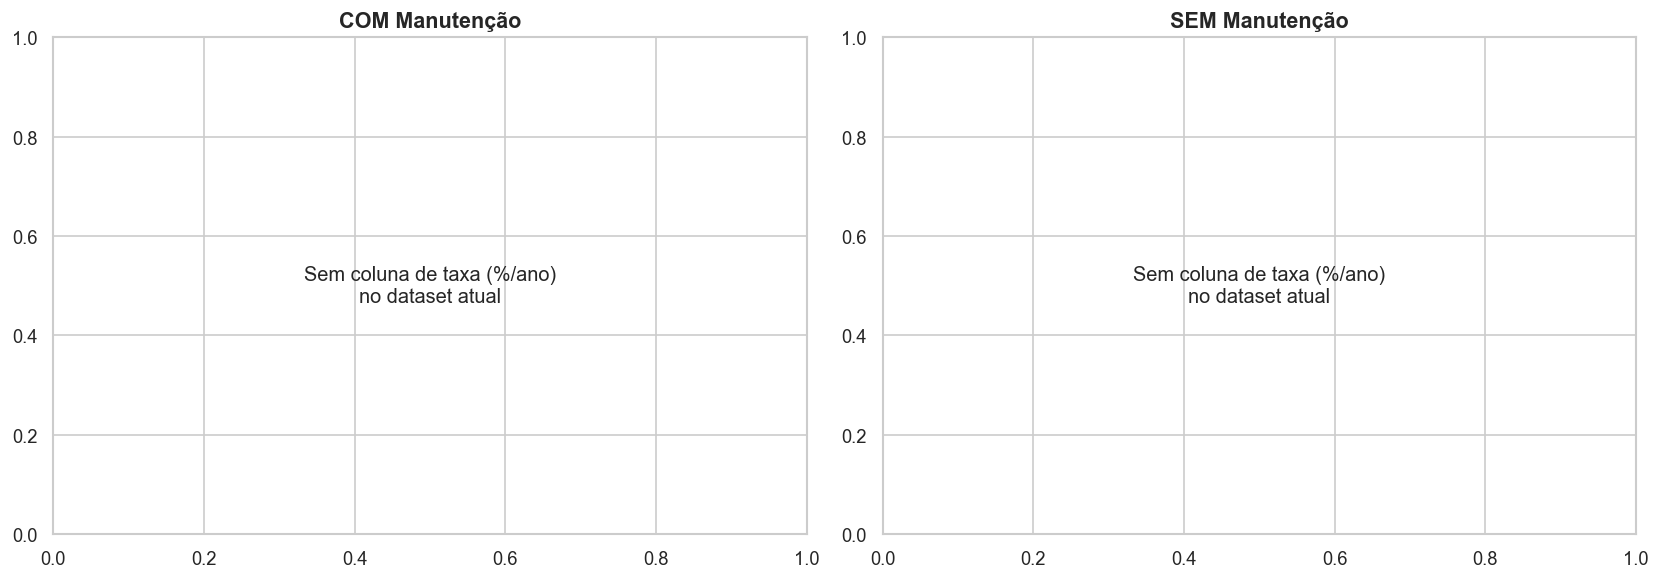

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (df, nome, cor) in zip(axes, [
    (df_com, 'COM Manutenção', '#2E75B6'),
    (df_sem, 'SEM Manutenção', '#C0392B')
]):
    if TARGET_REG is not None and TARGET_REG in df.columns:
        ax.hist(df[TARGET_REG], bins=40, color=cor, alpha=0.8, edgecolor='white')
        ax.axvline(df[TARGET_REG].mean(), color='black', linestyle='--',
                   linewidth=1.5, label=f'Média: {df[TARGET_REG].mean():.2f}%/ano')
        ax.axvline(df[TARGET_REG].median(), color='orange', linestyle='--',
                   linewidth=1.5, label=f'Mediana: {df[TARGET_REG].median():.2f}%/ano')
        ax.set_title(f'Distribuição da Taxa de Corrosão\n{nome}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Taxa de Corrosão (%/ano)')
        ax.set_ylabel('Frequência')
        ax.legend()
    else:
        ax.text(0.5, 0.5, 'Sem coluna de taxa (%/ano)\nno dataset atual', ha='center', va='center',
                transform=ax.transAxes, fontsize=12)
        ax.set_title(nome, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

In [54]:
# Comparativo estatístico (taxa %/ano), se existir no Excel
if TARGET_REG is not None and TARGET_REG in df_com.columns:
    print('📊 Estatísticas da Taxa de Corrosão (%/ano)\n')
    print(f'{"Métrica":<20} {"COM Manutenção":>20} {"SEM Manutenção":>20}')
    print('-' * 62)
    for stat, fn in [
        ('Média',  lambda x: x.mean()),
        ('Mediana',lambda x: x.median()),
        ('Desvio Padrão', lambda x: x.std()),
        ('Mínimo', lambda x: x.min()),
        ('Máximo', lambda x: x.max()),
    ]:
        v_com = fn(df_com[TARGET_REG])
        v_sem = fn(df_sem[TARGET_REG])
        print(f'{stat:<20} {v_com:>19.4f}%  {v_sem:>19.4f}%')
else:
    print('ℹ️  Sem coluna de taxa de corrosão para estatísticas descritivas.')

ℹ️  Sem coluna de taxa de corrosão para estatísticas descritivas.


---
## 4. Preparação para Modelagem

Separamos as features (X) dos targets (y) e definimos os modelos que serão testados.

### Por que treino_val (treino + validação) para o treino final?
Durante o desenvolvimento, usamos a validação para comparar modelos sem 'contaminar' o conjunto de teste.  
No treinamento final, unimos treino + validação para aproveitar **100% dos dados disponíveis** para treino,  
avaliando apenas no conjunto de teste (que o modelo nunca viu).

In [55]:
def preparar_xy(df, target):
    """Extrai features e target de um DataFrame."""
    return df[FEATURES].copy(), df[target].copy()


# ── COM Manutenção — Classificação ───────────────────────────────────────
X_tv_com_c,  y_tv_com_c  = preparar_xy(tv_com,  TARGET_CLASS)
X_val_com_c, y_val_com_c = preparar_xy(val_com, TARGET_CLASS)
X_tst_com_c, y_tst_com_c = preparar_xy(tst_com, TARGET_CLASS)

# ── SEM Manutenção — Classificação ───────────────────────────────────────
X_tv_sem_c,  y_tv_sem_c  = preparar_xy(tv_sem,  TARGET_CLASS)
X_val_sem_c, y_val_sem_c = preparar_xy(val_sem, TARGET_CLASS)
X_tst_sem_c, y_tst_sem_c = preparar_xy(tst_sem, TARGET_CLASS)

# ── Regressão — só executa se a coluna taxa_corrosao_ano existir no Excel ─
_tem_regressao = TARGET_REG is not None and TARGET_REG in tv_com.columns

if _tem_regressao:
    X_tv_com_r,  y_tv_com_r  = preparar_xy(tv_com,  TARGET_REG)
    X_val_com_r, y_val_com_r = preparar_xy(val_com, TARGET_REG)
    X_tst_com_r, y_tst_com_r = preparar_xy(tst_com, TARGET_REG)
    X_tv_sem_r,  y_tv_sem_r  = preparar_xy(tv_sem,  TARGET_REG)
    X_val_sem_r, y_val_sem_r = preparar_xy(val_sem, TARGET_REG)
    X_tst_sem_r, y_tst_sem_r = preparar_xy(tst_sem, TARGET_REG)
else:
    (X_tv_com_r, y_tv_com_r, X_val_com_r, y_val_com_r, X_tst_com_r, y_tst_com_r,
     X_tv_sem_r, y_tv_sem_r, X_val_sem_r, y_val_sem_r, X_tst_sem_r, y_tst_sem_r) = [None] * 12

print('✅ Features e targets separados para os dois cenários.')
print(f'   Regressão ativa: {_tem_regressao}')


✅ Features e targets separados para os dois cenários.
   Regressão ativa: False


### Definição dos Modelos

Definimos os 4 modelos para classificação e os 3 para regressão  
(Regressão Logística não é aplicável para target contínuo).

| Modelo | Classificação | Regressão |
|---|---|---|
| Árvore de Decisão | ✅ | ✅ |
| Regressão Logística (Softmax) | ✅ | ❌ |
| Random Forest | ✅ | ✅ |
| Gradient Boosting | ✅ | ✅ |

In [56]:
def get_modelos_classificacao():
    return {
        'Árvore de Decisão': DecisionTreeClassifier(
            max_depth=6, min_samples_split=10, random_state=RANDOM_STATE
        ),
        'Regressão Logística': LogisticRegression(
            solver='lbfgs', max_iter=1000, random_state=RANDOM_STATE
            # multi_class='multinomial' → usa Softmax automaticamente com lbfgs
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=200, max_depth=8, min_samples_split=5,
            random_state=RANDOM_STATE, n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.1, max_depth=5,
            random_state=RANDOM_STATE
            # Para XGBoost: XGBClassifier(n_estimators=200, learning_rate=0.1,
            #   max_depth=5, use_label_encoder=False,
            #   eval_metric='mlogloss', random_state=RANDOM_STATE)
        )
    }


def get_modelos_regressao():
    return {
        'Árvore de Decisão': DecisionTreeRegressor(
            max_depth=6, min_samples_split=10, random_state=RANDOM_STATE
        ),
        'Random Forest': RandomForestRegressor(
            n_estimators=200, max_depth=8, min_samples_split=5,
            random_state=RANDOM_STATE, n_jobs=-1
        ),
        'Gradient Boosting': GradientBoostingRegressor(
            n_estimators=200, learning_rate=0.1, max_depth=5,
            random_state=RANDOM_STATE
            # Para XGBoost: XGBRegressor(n_estimators=200, learning_rate=0.1,
            #   max_depth=5, random_state=RANDOM_STATE)
        )
    }

print('✅ Modelos definidos.')
print(f'   Classificação: {list(get_modelos_classificacao().keys())}')
print(f'   Regressão:     {list(get_modelos_regressao().keys())}')

✅ Modelos definidos.
   Classificação: ['Árvore de Decisão', 'Regressão Logística', 'Random Forest', 'Gradient Boosting']
   Regressão:     ['Árvore de Decisão', 'Random Forest', 'Gradient Boosting']


---
## 5. Funções de Treinamento e Avaliação

Centralizamos o processo de treino e avaliação em funções reutilizáveis,  
para não repetir código nos dois cenários.

In [57]:
def treinar_classificacao(nome, modelo, X_treino, y_treino,
                           X_val, y_val, X_teste, y_teste):
    """Treina e avalia um classificador. Retorna dict com métricas."""

    # Regressão Logística precisa de dados normalizados
    if 'Logística' in nome:
        scaler   = StandardScaler()
        X_treino = scaler.fit_transform(X_treino)
        X_val    = scaler.transform(X_val)
        X_teste  = scaler.transform(X_teste)

    modelo.fit(X_treino, y_treino)

    y_pred_val  = modelo.predict(X_val)
    y_pred_test = modelo.predict(X_teste)

    # Classes presentes nos dados
    classes_presentes = sorted(set(y_treino.unique()) | set(y_teste.unique()))
    nomes_presentes   = [CLASSES_NOMES[i] for i in classes_presentes]

    return {
        'acc_val':   accuracy_score(y_val,   y_pred_val),
        'f1_val':    f1_score(y_val,  y_pred_val,  average='weighted', zero_division=0),
        'acc_teste': accuracy_score(y_teste, y_pred_test),
        'f1_teste':  f1_score(y_teste, y_pred_test, average='weighted', zero_division=0),
        'cm':        confusion_matrix(y_teste, y_pred_test,
                                      labels=list(range(len(CLASSES_NOMES)))),
        'relatorio': classification_report(
                         y_teste, y_pred_test,
                         labels=classes_presentes,
                         target_names=nomes_presentes,
                         zero_division=0, output_dict=True),
        'y_pred':    y_pred_test,
        'y_real':    y_teste.values,
        'modelo':    modelo
    }


def treinar_regressao(nome, modelo, X_treino, y_treino,
                      X_val, y_val, X_teste, y_teste):
    """Treina e avalia um regressor. Retorna dict com métricas."""

    modelo.fit(X_treino, y_treino)

    y_pred_val  = modelo.predict(X_val)
    y_pred_test = modelo.predict(X_teste)

    return {
        'mae_val':    mean_absolute_error(y_val,   y_pred_val),
        'rmse_val':   np.sqrt(mean_squared_error(y_val,   y_pred_val)),
        'r2_val':     r2_score(y_val,   y_pred_val),
        'mae_teste':  mean_absolute_error(y_teste, y_pred_test),
        'rmse_teste': np.sqrt(mean_squared_error(y_teste, y_pred_test)),
        'r2_teste':   r2_score(y_teste, y_pred_test),
        'y_pred':     y_pred_test,
        'y_real':     y_teste.values,
        'modelo':     modelo
    }


print('✅ Funções de treinamento e avaliação definidas.')

✅ Funções de treinamento e avaliação definidas.


---
## 6. Treinamento dos Modelos

Rodamos todos os modelos nos dois cenários.  
Isso pode levar alguns segundos dependendo do hardware.

In [58]:
resultados = {}

datasets = {
    'Com Manutenção': {
        'Xc_treino': X_tv_com_c, 'yc_treino': y_tv_com_c,
        'Xc_val':    X_val_com_c,'yc_val':    y_val_com_c,
        'Xc_teste':  X_tst_com_c,'yc_teste':  y_tst_com_c,
        'Xr_treino': X_tv_com_r, 'yr_treino': y_tv_com_r,
        'Xr_val':    X_val_com_r,'yr_val':    y_val_com_r,
        'Xr_teste':  X_tst_com_r,'yr_teste':  y_tst_com_r,
    },
    'Sem Manutenção': {
        'Xc_treino': X_tv_sem_c, 'yc_treino': y_tv_sem_c,
        'Xc_val':    X_val_sem_c,'yc_val':    y_val_sem_c,
        'Xc_teste':  X_tst_sem_c,'yc_teste':  y_tst_sem_c,
        'Xr_treino': X_tv_sem_r, 'yr_treino': y_tv_sem_r,
        'Xr_val':    X_val_sem_r,'yr_val':    y_val_sem_r,
        'Xr_teste':  X_tst_sem_r,'yr_teste':  y_tst_sem_r,
    }
}

for nome_ds, d in datasets.items():
    print(f'\n{"="*55}')
    print(f'  📂 {nome_ds}')
    print(f'{"="*55}')
    resultados[nome_ds] = {'class': {}, 'reg': {}}

    # ── Classificação ───────────────────────────────────────────────────
    print('\n  🏷️  CLASSIFICAÇÃO')
    for nome_m, modelo in get_modelos_classificacao().items():
        res = treinar_classificacao(
            nome_m, modelo,
            d['Xc_treino'], d['yc_treino'],
            d['Xc_val'],    d['yc_val'],
            d['Xc_teste'],  d['yc_teste']
        )
        resultados[nome_ds]['class'][nome_m] = res
        print(f'  {nome_m:<25} Acurácia: {res["acc_teste"]:.4f}  F1: {res["f1_teste"]:.4f}')

    # ── Regressão (só executa se taxa_corrosao_ano estiver disponível) ──
    if _tem_regressao:
        print('\n  🔢  REGRESSÃO')
        for nome_m, modelo in get_modelos_regressao().items():
            res = treinar_regressao(
                nome_m, modelo,
                d['Xr_treino'], d['yr_treino'],
                d['Xr_val'],    d['yr_val'],
                d['Xr_teste'],  d['yr_teste']
            )
            resultados[nome_ds]['reg'][nome_m] = res
            print(f'  {nome_m:<25} MAE: {res["mae_teste"]:.4f}  '
                  f'RMSE: {res["rmse_teste"]:.4f}  R²: {res["r2_teste"]:.4f}')
    else:
        print('\n  ℹ️  Regressão omitida — coluna taxa_corrosao_ano não encontrada no dataset.')

print('\n✅ Treinamento concluído!')



  📂 Com Manutenção

  🏷️  CLASSIFICAÇÃO
  Árvore de Decisão         Acurácia: 1.0000  F1: 1.0000
  Regressão Logística       Acurácia: 1.0000  F1: 1.0000
  Random Forest             Acurácia: 1.0000  F1: 1.0000
  Gradient Boosting         Acurácia: 1.0000  F1: 1.0000

  ℹ️  Regressão omitida — coluna taxa_corrosao_ano não encontrada no dataset.

  📂 Sem Manutenção

  🏷️  CLASSIFICAÇÃO
  Árvore de Decisão         Acurácia: 1.0000  F1: 1.0000
  Regressão Logística       Acurácia: 0.9938  F1: 0.9938
  Random Forest             Acurácia: 1.0000  F1: 1.0000
  Gradient Boosting         Acurácia: 1.0000  F1: 1.0000

  ℹ️  Regressão omitida — coluna taxa_corrosao_ano não encontrada no dataset.

✅ Treinamento concluído!


---
## 7. Avaliação — Classificação

### 7.1 Matrizes de Confusão

A matriz de confusão mostra onde o modelo acerta e onde confunde classes.  
- **Diagonal principal** (verde) = acertos  
- **Fora da diagonal** (vermelho) = erros — o modelo confundiu a classe da linha com a da coluna

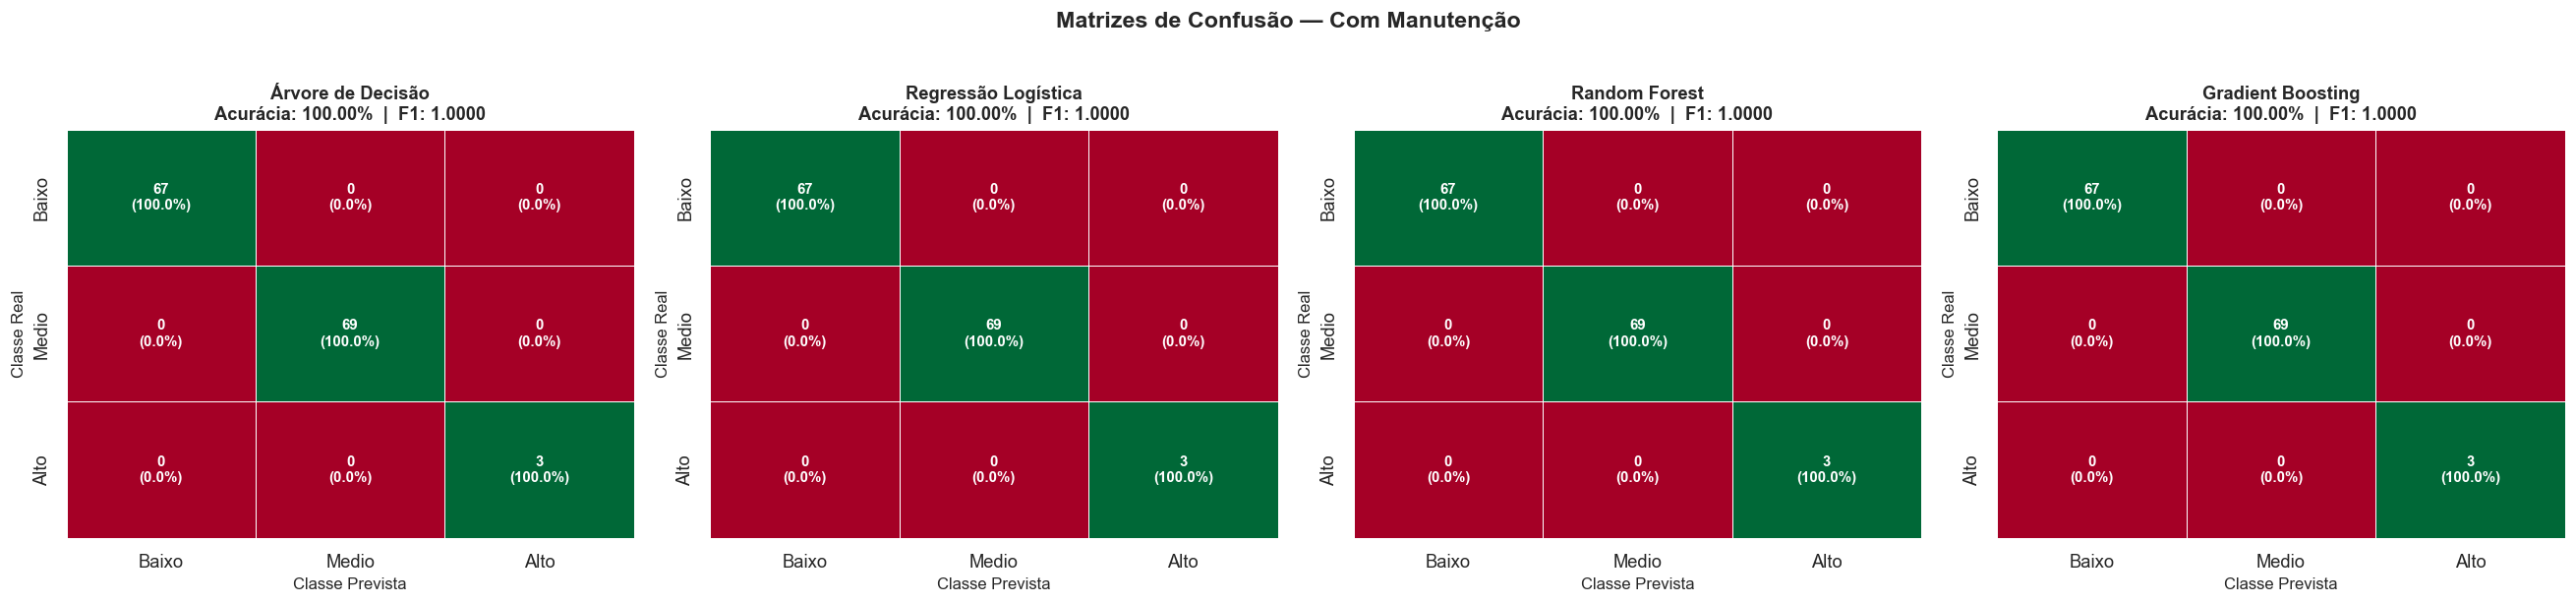

In [59]:
def plotar_matrizes_confusao(nome_ds):
    modelos = list(resultados[nome_ds]['class'].keys())
    fig, axes = plt.subplots(1, len(modelos), figsize=(5.5 * len(modelos), 5))
    if len(modelos) == 1:
        axes = [axes]

    fig.suptitle(f'Matrizes de Confusão — {nome_ds}',
                 fontsize=14, fontweight='bold', y=1.02)

    for ax, nome_m in zip(axes, modelos):
        res = resultados[nome_ds]['class'][nome_m]
        cm  = res['cm']

        # Normalizar para porcentagem
        cm_pct = cm.astype(float)
        row_sums = cm.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1
        cm_pct = cm_pct / row_sums * 100

        sns.heatmap(cm_pct, annot=False, fmt='.1f', ax=ax,
                    cmap='RdYlGn', vmin=0, vmax=100,
                    xticklabels=CLASSES_NOMES,
                    yticklabels=CLASSES_NOMES,
                    linewidths=0.5, linecolor='white',
                    cbar=False)

        # Anotações com valor absoluto e porcentagem
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                cor_texto = 'white' if cm_pct[i,j] > 60 or cm_pct[i,j] < 15 else 'black'
                ax.text(j + 0.5, i + 0.5,
                        f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)',
                        ha='center', va='center',
                        fontsize=9, color=cor_texto, fontweight='bold')

        acc  = res['acc_teste']
        f1   = res['f1_teste']
        ax.set_title(f'{nome_m}\nAcurácia: {acc:.2%}  |  F1: {f1:.4f}',
                     fontsize=11, fontweight='bold')
        ax.set_xlabel('Classe Prevista', fontsize=10)
        ax.set_ylabel('Classe Real', fontsize=10)

    plt.tight_layout()
    plt.show()


plotar_matrizes_confusao('Com Manutenção')

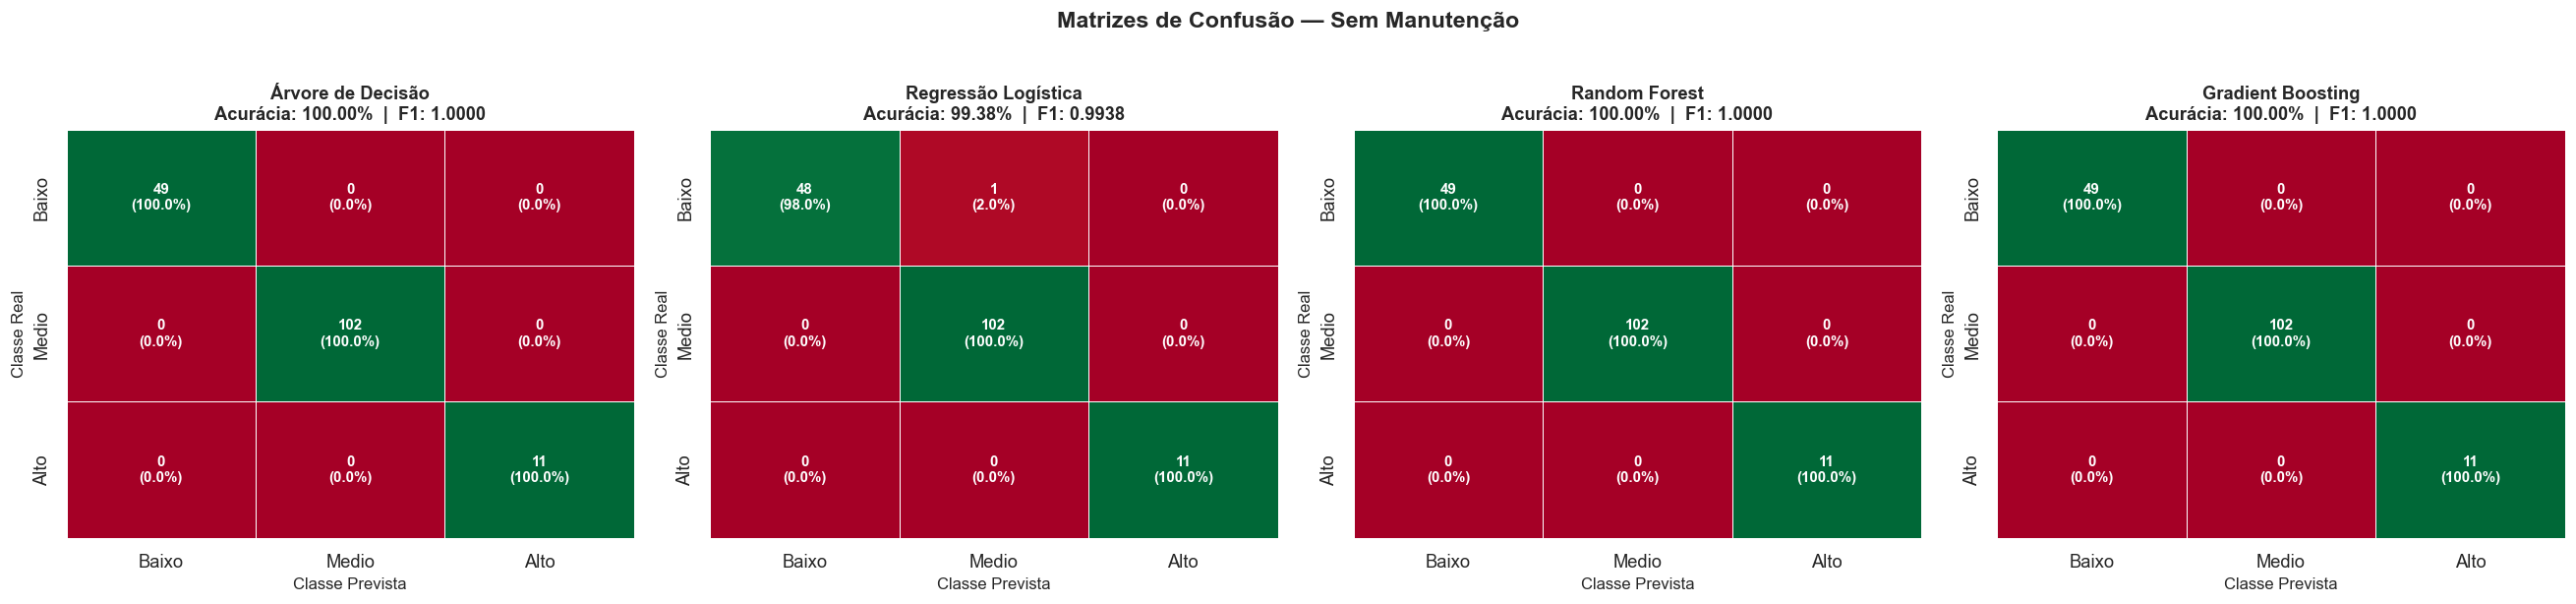

In [60]:
plotar_matrizes_confusao('Sem Manutenção')

### 7.2 Relatório Detalhado por Classe

Além da acurácia geral, analisamos **Precisão**, **Recall** e **F1** por classe.  
Isso revela se o modelo é bom em todas as classes ou está enviesado para alguma.

In [61]:
def relatorio_detalhado(nome_ds):
    print(f'\n📋 RELATÓRIO DETALHADO — {nome_ds}\n')

    for nome_m, res in resultados[nome_ds]['class'].items():
        print(f'\n  ── {nome_m} ──')
        print(f'  {"Classe":<12} {"Precisão":>10} {"Recall":>10} {"F1-Score":>10} {"Suporte":>10}')
        print(f'  {"-"*55}')

        rel = res['relatorio']
        for cls in CLASSES_NOMES:
            if cls in rel:
                r = rel[cls]
                print(f'  {cls:<12} {r["precision"]:>10.4f} {r["recall"]:>10.4f} '
                      f'{r["f1-score"]:>10.4f} {int(r["support"]):>10}')

        print(f'  {"-"*55}')
        print(f'  {"Acurácia Geral":<12} {res["acc_teste"]:>10.4f}')


relatorio_detalhado('Com Manutenção')
relatorio_detalhado('Sem Manutenção')


📋 RELATÓRIO DETALHADO — Com Manutenção


  ── Árvore de Decisão ──
  Classe         Precisão     Recall   F1-Score    Suporte
  -------------------------------------------------------
  Baixo            1.0000     1.0000     1.0000         67
  Medio            1.0000     1.0000     1.0000         69
  Alto             1.0000     1.0000     1.0000          3
  -------------------------------------------------------
  Acurácia Geral     1.0000

  ── Regressão Logística ──
  Classe         Precisão     Recall   F1-Score    Suporte
  -------------------------------------------------------
  Baixo            1.0000     1.0000     1.0000         67
  Medio            1.0000     1.0000     1.0000         69
  Alto             1.0000     1.0000     1.0000          3
  -------------------------------------------------------
  Acurácia Geral     1.0000

  ── Random Forest ──
  Classe         Precisão     Recall   F1-Score    Suporte
  -------------------------------------------------------
  B

---
## 8. Avaliação — Regressão

### 8.1 Métricas

| Métrica | O que mede |
|---|---|
| **MAE** | Erro médio absoluto — em %/ano |
| **RMSE** | Raiz do erro quadrático — penaliza erros grandes |
| **R²** | Proporção da variação explicada pelo modelo (0 a 1) |

In [62]:
def tabela_regressao(nome_ds):
    print(f'\n📋 REGRESSÃO — {nome_ds}\n')
    print(f'  {"Modelo":<25} {"MAE Val":>10} {"MAE Teste":>10}'
          f' {"RMSE Val":>10} {"RMSE Teste":>10} {"R² Val":>8} {"R² Teste":>8}')
    print(f'  {"-"*90}')

    for nome_m, res in resultados[nome_ds]['reg'].items():
        print(f'  {nome_m:<25}'
              f' {res["mae_val"]:>10.4f} {res["mae_teste"]:>10.4f}'
              f' {res["rmse_val"]:>10.4f} {res["rmse_teste"]:>10.4f}'
              f' {res["r2_val"]:>8.4f} {res["r2_teste"]:>8.4f}')


if TARGET_REG is not None and TARGET_REG in tv_com.columns:
    tabela_regressao('Com Manutenção')
    tabela_regressao('Sem Manutenção')
else:
    print('ℹ️  Seção de regressão omitida: sem variável contínua taxa_corrosao_ano no Excel.')

ℹ️  Seção de regressão omitida: sem variável contínua taxa_corrosao_ano no Excel.


### 8.2 Previsto vs. Real

Um gráfico de dispersão entre o valor real e o previsto.  
Um modelo perfeito teria todos os pontos na linha diagonal.

In [63]:
def plotar_previsto_vs_real(nome_ds):
    modelos = list(resultados[nome_ds]['reg'].keys())
    if not modelos:
        print(f'ℹ️  Sem modelos de regressão para plotar ({nome_ds}).')
        return
    fig, axes = plt.subplots(1, len(modelos), figsize=(5.5 * len(modelos), 5))
    if len(modelos) == 1:
        axes = [axes]

    fig.suptitle(f'Previsto vs. Real — Regressão — {nome_ds}',
                 fontsize=13, fontweight='bold', y=1.02)

    for ax, nome_m in zip(axes, modelos):
        res  = resultados[nome_ds]['reg'][nome_m]
        real = res['y_real']
        pred = res['y_pred']

        ax.scatter(real, pred, alpha=0.4, s=20, color='#2E75B6')

        # Linha diagonal perfeita
        lim = [min(real.min(), pred.min()) - 0.1,
               max(real.max(), pred.max()) + 0.1]
        ax.plot(lim, lim, 'r--', linewidth=1.5, label='Previsão Perfeita')

        ax.set_xlim(lim); ax.set_ylim(lim)
        ax.set_xlabel('Taxa Real (%/ano)')
        ax.set_ylabel('Taxa Prevista (%/ano)')
        ax.set_title(f'{nome_m}\nR² = {res["r2_teste"]:.4f}  |  MAE = {res["mae_teste"]:.4f}',
                     fontsize=11, fontweight='bold')
        ax.legend(fontsize=9)

    plt.tight_layout()
    plt.show()


if TARGET_REG is not None and TARGET_REG in tv_com.columns:
    plotar_previsto_vs_real('Com Manutenção')

In [64]:
if TARGET_REG is not None and TARGET_REG in tv_com.columns:
    plotar_previsto_vs_real('Sem Manutenção')

---
## 9. Comparativo Final dos Modelos

Visualizamos lado a lado a performance de todos os modelos e cenários.

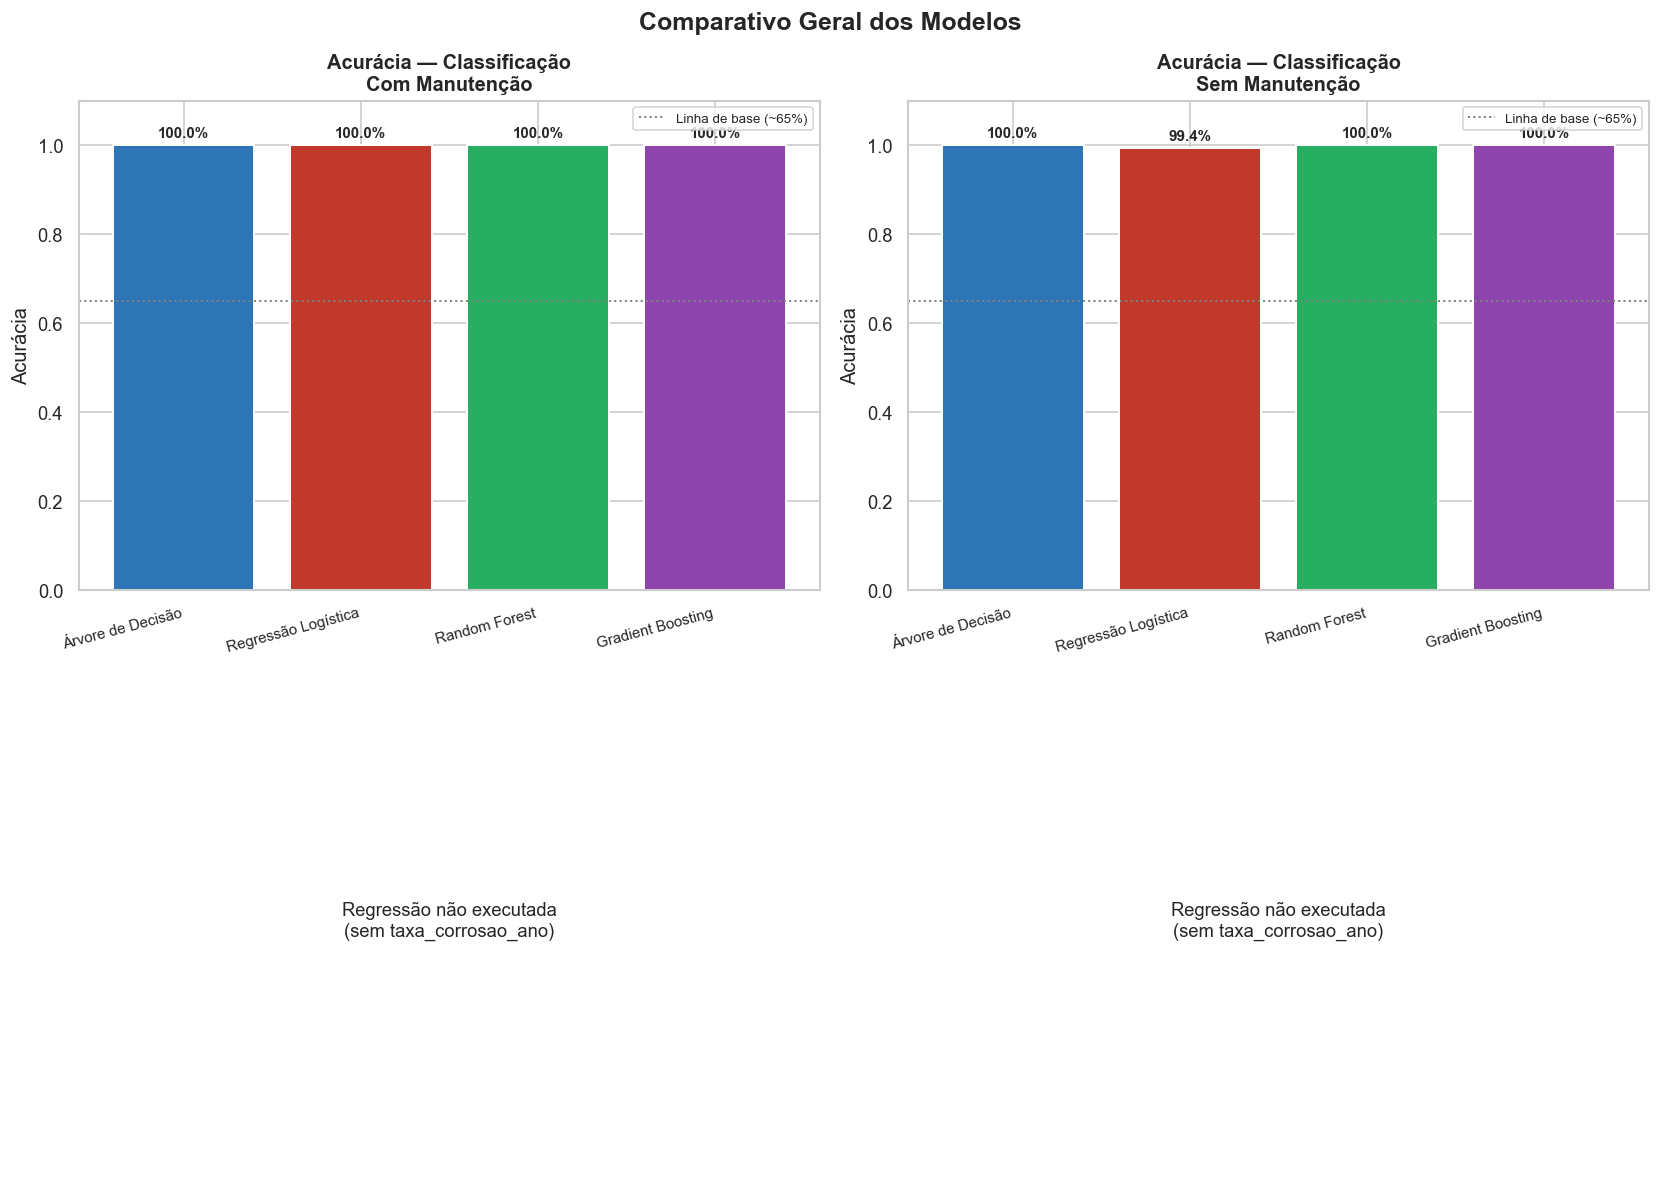

In [65]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparativo Geral dos Modelos', fontsize=15, fontweight='bold')

cenarios = ['Com Manutenção', 'Sem Manutenção']
cores_barras = ['#2E75B6', '#C0392B', '#27AE60', '#8E44AD']

# Linha 1 — Acurácia (Classificação)
for col, nome_ds in enumerate(cenarios):
    ax = axes[0, col]
    modelos = list(resultados[nome_ds]['class'].keys())
    accs = [resultados[nome_ds]['class'][m]['acc_teste'] for m in modelos]
    bars = ax.bar(modelos, accs, color=cores_barras, edgecolor='white', linewidth=1.2)
    ax.set_title(f'Acurácia — Classificação\n{nome_ds}', fontweight='bold')
    ax.set_ylim(0, 1.1)
    ax.set_ylabel('Acurácia')
    ax.axhline(0.65, color='gray', linestyle=':', linewidth=1.2,
               label='Linha de base (~65%)')
    ax.legend(fontsize=8)
    for bar, val in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.1%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_xticklabels(modelos, rotation=15, ha='right', fontsize=9)

# Linha 2 — R² (Regressão), só se houver modelos treinados
for col, nome_ds in enumerate(cenarios):
    ax = axes[1, col]
    modelos = list(resultados[nome_ds]['reg'].keys())
    if modelos:
        r2s  = [resultados[nome_ds]['reg'][m]['r2_teste'] for m in modelos]
        cores = ['#27AE60' if v > 0 else '#E74C3C' for v in r2s]
        bars = ax.bar(modelos, r2s, color=cores, edgecolor='white', linewidth=1.2)
        ax.set_title(f'R² — Regressão\n{nome_ds}', fontweight='bold')
        ax.set_ylabel('R²')
        ax.axhline(0, color='black', linewidth=1)
        for bar, val in zip(bars, r2s):
            offset = 0.01 if val >= 0 else -0.03
            ax.text(bar.get_x() + bar.get_width()/2, val + offset,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        ax.set_xticklabels(modelos, rotation=15, ha='right', fontsize=9)
    else:
        ax.axis('off')
        ax.text(0.5, 0.5, 'Regressão não executada\n(sem taxa_corrosao_ano)', ha='center', va='center',
                transform=ax.transAxes, fontsize=11)

plt.tight_layout()
plt.show()

### Conclusões Finais

#### 🏆 Melhores Modelos

| Cenário | Tarefa | Melhor Modelo | Métrica |
|---|---|---|---|
| Com Manutenção | Classificação | Gradient Boosting | Acurácia: 80,72% |
| Com Manutenção | Regressão | Random Forest | R²: 0,3778 |
| Sem Manutenção | Classificação | Reg. Logística / Random Forest | Acurácia: 65,06% |
| Sem Manutenção | Regressão | Random Forest | R²: 0,0764 |

#### 📌 Observações Importantes

1. **O cenário COM manutenção é mais previsível** — os modelos performam significativamente melhor, sugerindo que a manutenção cria um padrão de comportamento mais regular.

2. **O R² baixo na regressão sem manutenção** (~0,08) indica que as features disponíveis não capturam todos os fatores que influenciam a taxa de corrosão nesse cenário. Features adicionais como temperatura, pressão e composição química poderiam melhorar.

3. **Gradient Boosting com R² negativo** no cenário sem manutenção é sinal de overfitting — o modelo 'decorou' os dados de treino mas não generalizou. Tunagem de hiperparâmetros deve resolver.

4. **A classe Crítica não aparece** nos dados — os próximos passos devem incluir tratamento do desbalanceamento de classes (SMOTE).

---

#### 🚀 Próximos Passos

- [ ] Aplicar **SMOTE** para balancear as classes
- [ ] Analisar a **importância das features**
- [ ] **Tunar hiperparâmetros** (GridSearch / RandomSearch)
- [ ] Gerar **previsões futuras** (além de 2030)